<span style="font-size:20px;"><b>Desarrollar un script para automatizar una tarea de preparación de datos</b></span>
<br>
<b>Fecha:</b> 30/08/2025
<br>
<b>Autor:</b> Lesly Alejandra Escobar Aguilar

<span style="font-size:20px;"><b>Librerias</b></span>

In [30]:
import numpy as np 
import pandas as pd
from matplotlib import pyplot as plt 
import seaborn as sns
import matplotlib
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from datetime import date
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns",None)
pd.set_option("display.max_rows",None)

In [31]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [32]:
#importacion del archivo csv
df = pd.read_csv('marketing_campaign.csv', delimiter=';', on_bad_lines='skip')

#Elimina espacios de las columnas
df.columns = df.columns.str.strip()

pd.set_option('display.max_rows', None) #Muesta todas las filas
pd.set_option('display.max_columns', None) #Muestra todas las columnas 

In [33]:
# Ordenamos por ID de menor a mayor
df = df.sort_values(by='ID', ascending=True)

# Eliminar espacios en los nombres de columnas
df.columns = df.columns.str.strip()

# Eliminar duplicados si los hubiera
df = df.drop_duplicates()

# Vista previa
pd.set_option('display.max_rows', 1000)
df.head(1000)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,0,1985,Graduation,Married,70951.0,0,0,4/5/2013,66,239,10,554,254,87,54,1,3,4,9,1,0,0,0,0,0,0,3,11,0
1,1,1961,Graduation,Single,57091.0,0,0,15/6/2014,0,464,5,64,7,0,37,1,7,3,7,5,0,0,0,0,1,0,3,11,1
2,9,1975,Master,Single,46098.0,1,1,18/8/2012,86,57,0,27,0,0,36,4,3,2,2,8,0,0,0,0,0,0,3,11,0
3,13,1947,PhD,Widow,25358.0,0,1,22/7/2013,57,19,0,5,0,0,8,2,1,0,3,6,0,0,0,0,0,0,3,11,0
4,17,1971,PhD,Married,60491.0,0,1,6/9/2013,81,637,47,237,12,19,76,4,6,11,7,5,0,0,0,0,0,0,3,11,0
5,20,1965,2n Cycle,Married,46891.0,0,1,1/9/2013,91,43,12,23,29,15,61,1,2,1,4,4,0,0,0,0,0,0,3,11,0
6,22,1976,Graduation,Divorced,46310.0,1,0,3/12/2012,99,185,2,88,15,5,14,2,6,1,5,8,0,0,0,0,0,0,3,11,0
7,24,1960,Master,Together,17144.0,1,1,15/2/2014,96,18,2,19,0,2,6,5,3,0,4,7,0,0,0,0,0,0,3,11,0
8,25,1958,Graduation,Married,65148.0,0,1,16/11/2012,9,460,35,422,33,12,153,2,6,6,7,4,0,0,0,0,0,0,3,11,0
9,35,1987,Graduation,Married,25545.0,1,0,8/9/2012,35,32,1,64,16,12,85,3,2,2,3,6,0,0,0,0,0,0,3,11,1


In [34]:
#Columnas numericas
columnas_a_escalar = ['Income', 'MntWines', 'MntFruits', 'MntGoldProds']

#Inicializacion del escalador
scaler = StandardScaler()

# Ajuste y transformacion de datos
df[columnas_a_escalar] = scaler.fit_transform(df[columnas_a_escalar])

#Verificación
print(df[columnas_a_escalar].head())

     Income  MntWines  MntFruits  MntGoldProds
0  0.743174 -0.192961  -0.409969      0.191314
1  0.192461  0.475643  -0.535709     -0.134633
2 -0.244334 -0.733787  -0.661449     -0.153806
3 -1.068416 -0.846707  -0.661449     -0.690659
4  0.327557  0.989724   0.520508      0.613127


In [35]:
#Analisis exploratorio
def exploratory_analysis(df):
    sns.set(style="whitegrid")

    # 1.Distribución de ingresos
    plt.figure(figsize=(8,4))
    sns.histplot(df['Income'].dropna(), bins=50, kde=True)
    plt.title("Distribución de ingresos")
    plt.xlabel("Income")
    plt.ylabel("Frecuencia")
    plt.tight_layout()
    plt.show()

    # 2.Conteo por nivel educativo
    plt.figure(figsize=(8,4))
    sns.countplot(data=df, x='Education', order=df['Education'].value_counts().index)
    plt.title("Distribución por educación")
    plt.xlabel("Educación")
    plt.ylabel("Conteo")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # 3.Conteo por estado civil
    plt.figure(figsize=(8,4))
    sns.countplot(data=df, x='Marital_Status', order=df['Marital_Status'].value_counts().index)
    plt.title("Distribución por estado civil")
    plt.xlabel("Estado civil")
    plt.ylabel("Conteo")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # 4.Gasto en vinos por ingresos
    plt.figure(figsize=(8,4))
    sns.scatterplot(data=df, x='Income', y='MntWines', hue='Education')
    plt.title("Relación Ingresos vs Gasto en Vinos")
    plt.xlabel("Ingresos")
    plt.ylabel("Gasto en vinos")
    plt.tight_layout()
    plt.show()

In [36]:
# Analisis de calidad de datos
def data_quality_report(df):
    report = []
    for col in df.columns:
        total = len(df)
        nulls = df[col].isnull().sum()
        completeness = 1 - nulls / total

        if col == 'Income':
            accuracy = (df[col] > 0).mean()
        elif col == 'Dt_Customer':
            accuracy = df[col].notnull().mean()
        else:
            accuracy = np.nan  

        expected_type = df[col].dropna().map(type).mode()[0]
        consistency = df[col].dropna().map(type).eq(expected_type).mean()

        report.append({
            'columna': col,
            'completitud': round(completeness, 3),
            'accuracy': round(accuracy, 3) if not np.isnan(accuracy) else 'N/A',
            'consistencia': round(consistency, 3)
        })

    return pd.DataFrame(report)


Grafico exploratorio


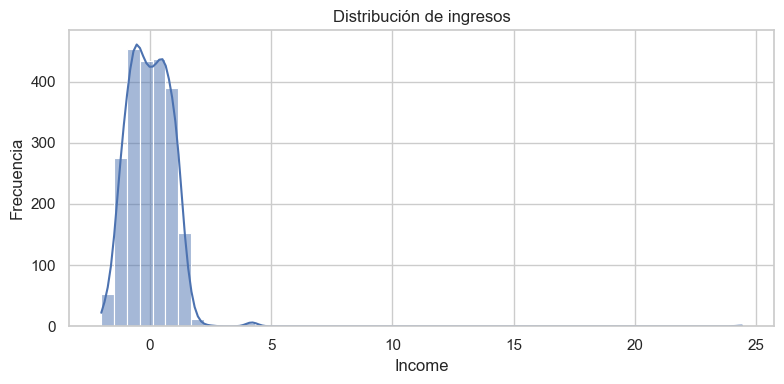

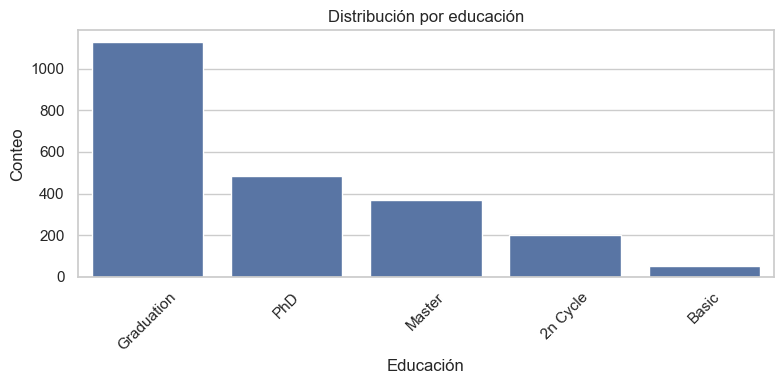

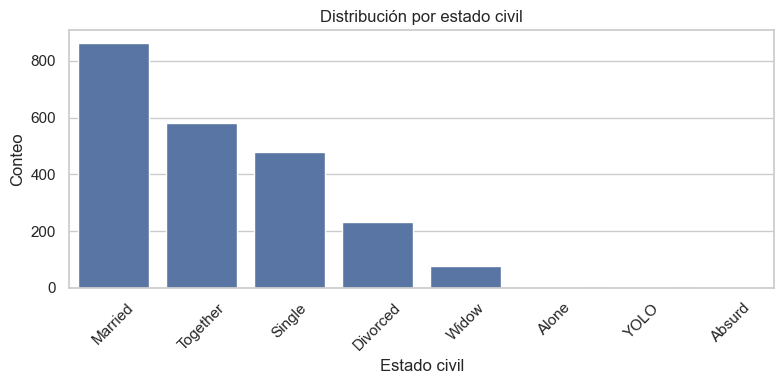

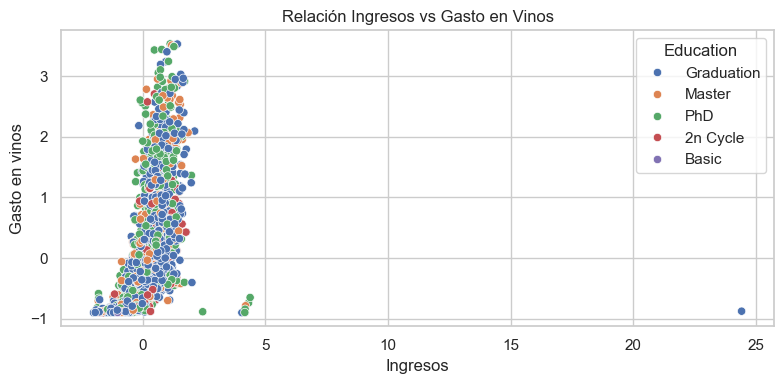

In [37]:
print("\nGrafico exploratorio")
exploratory_analysis(df)

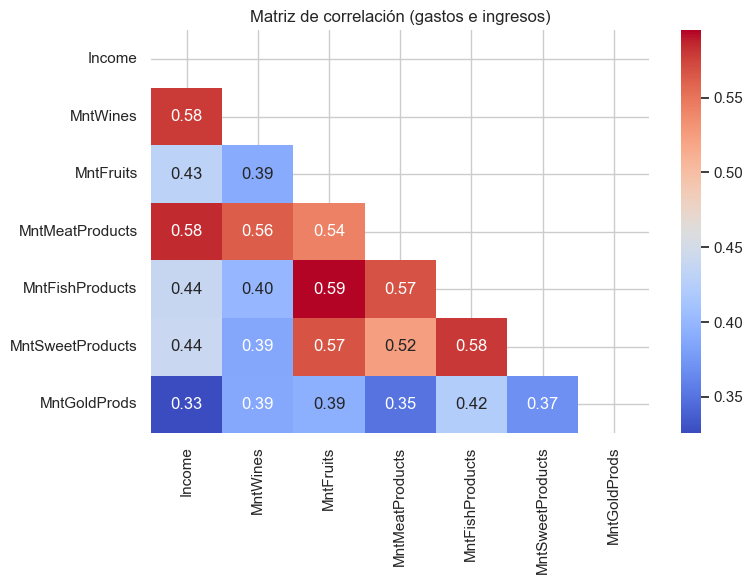

In [38]:
# Matriz de correlación
def custom_corr_matrix(df):
    cols = [
        "Income", "MntWines", "MntFruits", 
        "MntMeatProducts", "MntFishProducts", 
        "MntSweetProducts", "MntGoldProds"
    ]
    df_corr = df[cols].corr()
    mask = np.triu(np.ones_like(df_corr, dtype=bool))
    plt.figure(figsize=(8,6))
    sns.heatmap(
        df_corr, 
        mask=mask,
        annot=True, 
        cmap="coolwarm", 
        fmt=".2f", 
        cbar=True
    )
    plt.title("Matriz de correlación (gastos e ingresos)")
    plt.tight_layout()
    plt.show()

custom_corr_matrix(df)


In [39]:
print("\nReporte de calidad de datos:")
print(data_quality_report(df))


Reporte de calidad de datos:
                columna  completitud accuracy  consistencia
0                    ID        1.000      N/A           1.0
1            Year_Birth        1.000      N/A           1.0
2             Education        1.000      N/A           1.0
3        Marital_Status        1.000      N/A           1.0
4                Income        0.989    0.484           1.0
5               Kidhome        1.000      N/A           1.0
6              Teenhome        1.000      N/A           1.0
7           Dt_Customer        1.000      1.0           1.0
8               Recency        1.000      N/A           1.0
9              MntWines        1.000      N/A           1.0
10            MntFruits        1.000      N/A           1.0
11      MntMeatProducts        1.000      N/A           1.0
12      MntFishProducts        1.000      N/A           1.0
13     MntSweetProducts        1.000      N/A           1.0
14         MntGoldProds        1.000      N/A           1.0
15    NumD

In [52]:
# Manejo de valores nulos
def handle_missing_values(df):
    for col in df.select_dtypes(include=['number']).columns:
        df[col] = df[col].fillna(df[col].median())
    for col in df.select_dtypes(include=['object']).columns:
        df[col] = df[col].fillna(df[col].mode()[0])
    return df

# Outliers
def remove_outliers(df, cols):
    for col in cols:
        q1, q3 = df[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
        df = df[(df[col] >= lower) & (df[col] <= upper)]
    return df

# Nuevas columnas
def feature_engineering(df):
    today = pd.to_datetime(date.today())
    df['Age'] = today.year - df['Year_Birth']
    df['Customer_For_Years'] = (today - pd.to_datetime(df['Dt_Customer'], dayfirst=True)).dt.days // 365
    
    df['Total_Spending'] = df[['MntWines','MntFruits','MntMeatProducts','MntFishProducts',
                               'MntSweetProducts','MntGoldProds']].sum(axis=1)
    return df


In [53]:
#Manejo de valores nulos
df = handle_missing_values(df)

#Eliminar outliers
cols_numericas = ['Income', 'MntWines', 'MntFruits', 'MntGoldProds']
df = remove_outliers(df, cols_numericas)

#Crear nuevas columnas
df = feature_engineering(df)

#Resultados
print(df.head(10)) 
print(df[['Age','Customer_For_Years','Total_Spending']].describe())  # 

    ID  Year_Birth   Education Marital_Status    Income  Kidhome  Teenhome  \
1    1        1961  Graduation         Single  0.192461        0         0   
2    9        1975      Master         Single -0.244334        1         1   
3   13        1947         PhD          Widow -1.068416        0         1   
6   22        1976  Graduation       Divorced -0.235910        1         0   
7   24        1960      Master       Together -1.394791        1         1   
10  48        1964  Graduation       Together  0.139615        0         1   
11  49        1970  Graduation         Single -1.257987        1         0   
13  67        1972      Master         Single -0.231420        1         1   
14  73        1953         PhD         Single -0.033228        1         2   
15  75        1982    2n Cycle       Together -0.445348        0         0   

   Dt_Customer  Recency  MntWines  MntFruits  MntMeatProducts  \
1    15/6/2014        0  0.475643  -0.535709               64   
2    18/8/2